<div style="color:#3c4d5a; border-top:7px solid #42A5F5; border-bottom:7px solid #42A5F5; padding:8px; text-align:center; text-transform:uppercase">
  <h1>STREAMML - CARGA Y PREPARACION DE DATASETS</h1>
</div>

<strong>Proyecto:</strong> StreamML  | 
  <strong>Integrantes:</strong> Alexis Guaman y Cinthya Ramon  | 
  <strong>Modalidad:</strong> Machine Learning offline

<div id="descripcion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Descripción del proyecto</h2> </div>

El proyecto **Streaming Adaptativo y Predicción de Reducción de Calidad mediante Machine Learning (StreamML)** busca disminuir congelamientos, pérdida de frames e interrupciones en transmisiones en vivo realizadas sobre redes móviles, donde la capacidad de subida, la latencia, el jitter y la pérdida de paquetes pueden cambiar de forma repentina. La arquitectura integra un teléfono con VDO.Ninja, OBS Studio, MediaMTX y FFmpeg para capturar, procesar y retransmitir la señal hacia plataformas externas.

StreamML utiliza dos modelos supervisados con responsabilidades diferentes. El modelo **reactivo** analiza las condiciones actuales y recomienda uno de los perfiles `low`, `medium` o `high`. El modelo **predictivo** resume los últimos 600 segundos de capacidad de red y estima si el perfil podrá mantenerse durante los siguientes 600 segundos mediante las clases `maintain` y `downgrade_needed`. Sus resultados no controlan OBS directamente: un agente autónomo propio aplica margen de seguridad, histéresis, tiempos mínimos entre cambios y decisiones explicables para mantener, aumentar o reducir el perfil.

Cuando la señal principal desaparece, la política puede activar una escena de respaldo y restaurar el contenido en vivo únicamente después de confirmar una recuperación estable. El proyecto combina así preparación reproducible de datos, entrenamiento y versionado de modelos, inferencia validada, control operativo seguro, telemetría y una interfaz gráfica para configurar y supervisar el sistema. Las métricas offline demuestran el funcionamiento interno de la solución; la eficacia final debe confirmarse con pruebas IRL independientes en redes y plataformas reales.

<div id="objetivo" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Objetivo del notebook</h2> </div>

Este notebook construye una vision verificable de los dos problemas de aprendizaje del proyecto. El problema reactivo consiste en recomendar `low`, `medium` o `high` a partir de una medicion actual; el predictivo estima `maintain` o `downgrade_needed` usando estadisticas de una ventana historica y una etiqueta calculada en un intervalo estrictamente posterior.

Al finalizar se espera confirmar que ambos datasets tienen procedencia conocida, columnas compatibles con sus contratos, valores numericos validos, targets coherentes y particiones sin sesiones compartidas. Las tablas y graficos se calculan durante la ejecucion: no se insertan cifras manuales ni se generan observaciones sinteticas para cubrir ausencias.

<div id="requisitos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Requisitos, entradas y salida esperada</h2> </div>

El notebook requiere Python 3.11 y las dependencias de `requirements.txt`: pandas y NumPy para procesamiento, Matplotlib para graficos y Jupyter/nbformat para ejecucion. Desde la raiz se instalan con `pip install -r requirements.txt`.

Las entradas son `data/raw/source_manifest.json`, los dos CSV de `data/processed/` y los contratos de `src/streamml/config/`. Los datos brutos grandes permanecen locales; si una fuente necesaria falta, el flujo debe detenerse en lugar de sustituirla por datos sinteticos.

La salida esperada son dos datasets auditados, con variables y targets documentados, clases comprobadas y particiones por sesiones completas. Todas las rutas se resuelven respecto de la raiz del repositorio para que la ejecucion no dependa del equipo del autor.

<div id="contenido" style="color:#106ba3"><h3>Contenido</h3> </div>

- [Descripción del proyecto](#descripcion)
- [Objetivo](#objetivo)
- [Fundamentos metodologicos](#fundamentos-metodologicos)
- [Fase 1: Entorno y librerias](#fase-1-entorno-y-librerias)
- [Fase 2: Procedencia y licencia](#fase-2-procedencia-y-licencia)
- [Fase 3: Carga y revision inicial](#fase-3-carga-y-revision-inicial)
- [Fase 4: Contratos, variables y targets](#fase-4-contratos-variables-y-targets)
- [Fase 5: Limpieza y transformacion](#fase-5-limpieza-y-transformacion)
- [Fase 6: Analisis exploratorio](#fase-6-analisis-exploratorio)
- [Auditoria de calidad y riesgo](#auditoria-calidad)
- [Fase 7: Division por `session_id`](#fase-7-division-por-session-id)
- [Fase 8: Guardado y comprobacion final](#fase-8-guardado-y-comprobacion-final)
- [Conclusiones](#conclusiones)
- [Referencias](#referencias)

<div id="fundamentos-metodologicos" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fundamentos metodologicos</h2> </div>

La preparacion no es solo una tarea de formato: define que informacion puede aprender el modelo y que significado tienen sus resultados. Una columna mal tipada, una sesion repetida entre particiones o una variable futura incluida en las entradas puede producir metricas altas que no se sostendrian al inferir sobre una transmision nueva.

StreamML utiliza contratos JSON para fijar nombres, orden, unidades y columnas prohibidas. En el problema predictivo se separan dos tiempos: el historial produce las variables de entrada y el horizonte posterior produce la pseudoetiqueta. Esta frontera temporal se audita de manera explicita para impedir fuga de informacion.

<div id="fase-1-entorno-y-librerias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 1: Entorno y librerias</h2> </div>

La primera etapa importa las librerias de datos y visualizacion, localiza la raiz del repositorio y configura opciones de presentacion. La deteccion de la raiz permite ejecutar el notebook desde Jupyter abierto en `notebooks/` o desde la carpeta principal sin depender de una ruta personal.

Tambien se fija un formato comun para tablas y numeros. Esta configuracion no transforma los datos: crea un contexto reproducible para que las siguientes celdas encuentren exactamente los mismos archivos y muestren resultados comparables.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
print("Proyecto:", ROOT.name)

Proyecto: Adaptive-Streaming-ai


<div id="fase-2-procedencia-y-licencia" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 2: Procedencia y licencia</h2> </div>

Antes de analizar columnas se comprueba de donde proviene cada dataset. El manifiesto conserva nombre de la fuente, licencia, URL y hashes de los archivos conocidos. Estos datos permiten rastrear una observacion hasta su origen y distinguir mediciones publicas de resultados derivados por el proyecto.

La tabla presentada es una lectura del manifiesto; no modifica la procedencia. Esta separacion es importante porque las licencias y checksums son evidencia de reproducibilidad, no variables que deban entrar al entrenamiento.

In [2]:
manifest_path = ROOT / "data" / "raw" / "source_manifest.json"
source_manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
provenance = pd.DataFrame([
    {
        "dataset": source_manifest["reactive_source"]["dataset_name"],
        "role": "reactive",
        "license": source_manifest["reactive_source"]["license"],
        "url": source_manifest["reactive_source"]["url"],
    },
    {
        "dataset": source_manifest["dataset_name"],
        "role": "predictive",
        "license": source_manifest["license"],
        "url": source_manifest["source_url"],
    },
])
display(provenance)

,dataset,role,license,url
0,RTR-NetzTest Open Data,reactive,"Open data publication, see bundled LIZENZ.txt",https://www.netztest.at/en/Opendata
1,YouTube Dataset on Mobile Streaming for Intern...,predictive,CC BY 4.0,https://figshare.com/articles/dataset/YouTube_...


<div id="fase-3-carga-y-revision-inicial" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 3: Carga y revision inicial</h2> </div>

Los dos CSV oficiales se cargan sin alterar inicialmente su contenido. Se revisan cantidad de filas y columnas, sesiones unicas, duplicados, valores faltantes y tipos inferidos por pandas. El objetivo es detectar problemas antes de que una conversion silenciosa cambie su significado.

El resumen conjunto permite comparar la granularidad: el reactivo contiene mediciones puntuales, mientras el predictivo contiene ventanas temporales resumidas. Si una columna obligatoria faltara, las comprobaciones posteriores detendrian el notebook en lugar de continuar con un esquema incompleto.

In [3]:
reactive_path = ROOT / "data" / "processed" / "reactive_dataset.csv"
predictive_path = ROOT / "data" / "processed" / "predictive_dataset.csv"

reactive_raw = pd.read_csv(reactive_path)
predictive_raw = pd.read_csv(predictive_path)

overview = pd.DataFrame([
    {"dataset": "reactive", "rows": len(reactive_raw), "columns": reactive_raw.shape[1], "sessions": reactive_raw["session_id"].nunique(), "duplicates": reactive_raw.duplicated().sum(), "missing": int(reactive_raw.isna().sum().sum())},
    {"dataset": "predictive", "rows": len(predictive_raw), "columns": predictive_raw.shape[1], "sessions": predictive_raw["session_id"].nunique(), "duplicates": predictive_raw.duplicated().sum(), "missing": int(predictive_raw.isna().sum().sum())},
])
display(overview)
display(pd.DataFrame({"reactive_dtype": reactive_raw.dtypes.astype(str)}).head(15))
display(pd.DataFrame({"predictive_dtype": predictive_raw.dtypes.astype(str)}).head(20))

,dataset,rows,columns,sessions,duplicates,missing
0,reactive,26686,15,26686,0,0
1,predictive,4336,43,17,0,0


,reactive_dtype
source_dataset,str
source_version,str
session_id,str
timestamp_utc,str
provenance,str
upload_mbps,float64
download_mbps,float64
latency_ms,float64
upload_unit,str
download_unit,str


,predictive_dtype
source_dataset,str
source_version,int64
session_id,str
window_id,str
window_start_seconds,float64
window_end_seconds,float64
sampling_interval_seconds,float64
throughput_mean,float64
throughput_median,float64
throughput_min,float64


<div id="fase-4-contratos-variables-y-targets" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 4: Contratos, variables y targets</h2> </div>

Los contratos se tratan como la fuente de verdad para construir `X`. Esto evita seleccionar columnas por posicion o incluir accidentalmente identificadores, targets y campos futuros. Tambien permite que entrenamiento, inferencia y GUI compartan el mismo orden de variables.

El target reactivo representa el perfil recomendado. El predictivo es binario y separa mantenimiento de una reduccion necesaria. Las columnas futuras permanecen en el dataset para auditar como se obtuvo la etiqueta, pero la interseccion entre esas columnas y las variables del modelo debe ser vacia.

In [4]:
reactive_contract = json.loads((ROOT / "src" / "streamml" / "config" / "reactive_feature_contract.json").read_text(encoding="utf-8"))
predictive_contract = json.loads((ROOT / "src" / "streamml" / "config" / "predictive_feature_contract.json").read_text(encoding="utf-8"))

reactive_features = reactive_contract["features"]
predictive_features = predictive_contract["features"]
forbidden_predictive = predictive_contract["forbidden_input_columns"]

assert len(reactive_features) == reactive_contract["feature_count"] == 3
assert len(predictive_features) == predictive_contract["feature_count"] == 19
assert not set(predictive_features).intersection(forbidden_predictive)
assert set(reactive_features + ["target", "session_id"]).issubset(reactive_raw.columns)
assert set(predictive_features + ["target", "target_code", "session_id"]).issubset(predictive_raw.columns)

display(pd.DataFrame({"reactive_features": pd.Series(reactive_features)}))
display(pd.DataFrame({"predictive_features": pd.Series(predictive_features)}))

,reactive_features
0,upload_mbps
1,download_mbps
2,latency_ms


,predictive_features
0,throughput_mean
1,throughput_median
2,throughput_min
3,throughput_max
4,throughput_std
5,throughput_p10
6,throughput_p25
7,throughput_first
8,throughput_last
9,throughput_change


<div id="fase-5-limpieza-y-transformacion" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 5: Limpieza y transformacion</h2> </div>

La limpieza convierte a numerico solo las variables cuyo contrato exige valores cuantitativos, reemplaza infinitos por valores ausentes y descarta registros que no pueden utilizarse de forma segura. No se rellenan targets, identificadores ni campos futuros, porque una imputacion arbitraria modificaria la semantica de la observacion.

Despues se verifican las clases esperadas y la ausencia de nulos en las entradas. Estas aserciones convierten supuestos metodologicos en condiciones ejecutables: si los datos dejan de cumplirlos, el proceso falla antes de guardar o entrenar.

In [5]:
def clean_dataset(frame, numeric_columns, required_columns):
    cleaned = frame.copy()
    cleaned[numeric_columns] = cleaned[numeric_columns].apply(pd.to_numeric, errors="coerce")
    cleaned[numeric_columns] = cleaned[numeric_columns].replace([np.inf, -np.inf], np.nan)
    cleaned = cleaned.drop_duplicates().dropna(subset=required_columns).reset_index(drop=True)
    return cleaned

reactive = clean_dataset(
    reactive_raw,
    reactive_features + ["target_code"],
    reactive_features + ["target", "target_code", "session_id", "split"],
)
predictive = clean_dataset(
    predictive_raw,
    predictive_features + ["target_code"],
    predictive_features + ["target", "target_code", "session_id", "window_id"],
)

assert set(reactive["target"]) == {"low", "medium", "high"}
assert set(predictive["target"]) == {"maintain", "downgrade_needed"}
assert reactive[reactive_features].notna().all().all()
assert predictive[predictive_features].notna().all().all()

cleaning = pd.DataFrame([
    {"dataset": "reactive", "rows_before": len(reactive_raw), "rows_after": len(reactive), "removed": len(reactive_raw) - len(reactive)},
    {"dataset": "predictive", "rows_before": len(predictive_raw), "rows_after": len(predictive), "removed": len(predictive_raw) - len(predictive)},
])
display(cleaning)

,dataset,rows_before,rows_after,removed
0,reactive,26686,26686,0
1,predictive,4336,4336,0


<div id="fase-6-analisis-exploratorio" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 6: Analisis exploratorio</h2> </div>

El analisis descriptivo resume tendencia central, dispersion y rangos de las variables. Sirve para identificar escalas muy distintas, valores extremos y variables casi constantes que pueden influir en la eleccion del algoritmo o en la necesidad de escalado.

La distribucion de clases muestra si una categoria domina el dataset. Esta informacion justifica evaluar Macro F1 y balanced accuracy en el entrenamiento. El analisis no se utiliza para buscar un subconjunto de test conveniente; describe los datos manteniendo intacta la evaluacion final.

,count,mean,std,min,25%,50%,75%,max
upload_mbps,26686.0000,79.1127,324.8759,0.0030,9.4530,21.5245,50.5640,6137.0100
download_mbps,26686.0000,157.2924,316.4114,0.0040,27.7092,75.5770,167.0497,6276.3040
latency_ms,26686.0000,33.7401,57.7470,0.7000,13.3000,22.8000,35.0000,2362.5000


,count,mean,std,min,25%,50%,75%,max
throughput_mean,4336.0000,2.9730,6.1342,0.2500,0.5000,2.0000,2.0000,25.0000
throughput_median,4336.0000,2.9983,6.1297,0.2500,0.5000,2.0000,2.0000,25.0000
throughput_min,4336.0000,2.8664,6.1695,0.1500,0.5000,2.0000,2.0000,25.0000
throughput_max,4336.0000,3.0312,6.1236,0.2500,0.5000,2.0000,2.0000,25.0000
throughput_std,4336.0000,0.0613,0.2185,0.0000,0.0000,0.0000,0.0000,1.0822
throughput_p10,4336.0000,2.8844,6.1643,0.1500,0.5000,2.0000,2.0000,25.0000
throughput_p25,4336.0000,2.9288,6.1500,0.1500,0.5000,2.0000,2.0000,25.0000
throughput_first,4336.0000,2.9772,6.1404,0.1500,0.5000,2.0000,2.0000,25.0000
throughput_last,4336.0000,2.9983,6.1297,0.2500,0.5000,2.0000,2.0000,25.0000
throughput_change,4336.0000,0.0211,0.3692,-2.2500,0.0000,0.0000,0.0000,1.8500


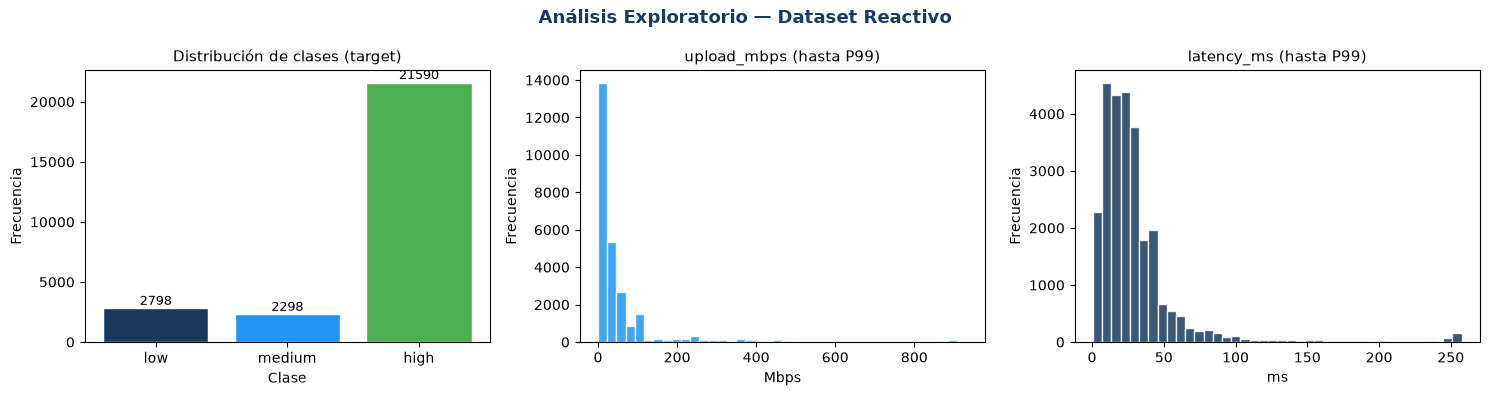

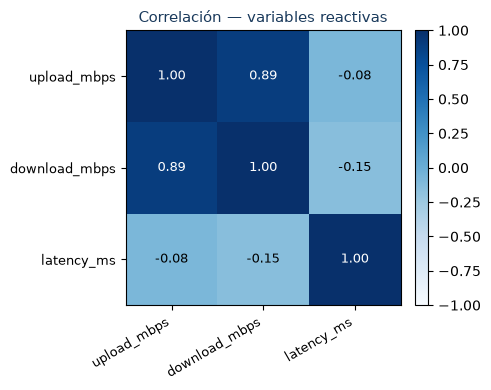

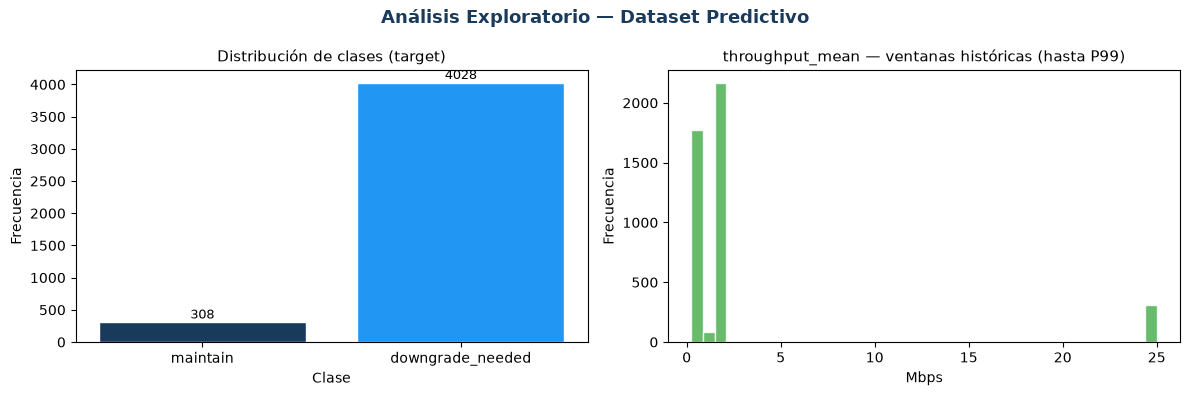

Graficos de analisis exploratorio generados correctamente.


In [6]:
# ── Paleta visual consistente ─────────────────────────────────────────────────
DARK_BLUE  = "#1a3a5c"
BLUE       = "#2196F3"
GREEN      = "#4CAF50"
LIGHT_GRAY = "#ECEFF1"
PALETTE    = [DARK_BLUE, BLUE, GREEN, LIGHT_GRAY]

display(reactive[reactive_features].describe().T)
display(predictive[predictive_features].describe().T)

# ── 1. Distribución de clases reactivas ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Análisis Exploratorio — Dataset Reactivo", fontsize=13, fontweight="bold", color=DARK_BLUE)

class_counts = reactive["target"].value_counts().reindex(["low", "medium", "high"])
axes[0].bar(class_counts.index, class_counts.values,
            color=[DARK_BLUE, BLUE, GREEN], edgecolor="white")
axes[0].set_title("Distribución de clases (target)", fontsize=11)
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Frecuencia")
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha="center", va="bottom", fontsize=9)

p99_up = reactive["upload_mbps"].quantile(0.99)
upload_filtered = reactive.loc[reactive["upload_mbps"] <= p99_up, "upload_mbps"]
axes[1].hist(upload_filtered, bins=40, color=BLUE, edgecolor="white", alpha=0.85)
axes[1].set_title("upload_mbps (hasta P99)", fontsize=11)
axes[1].set_xlabel("Mbps")
axes[1].set_ylabel("Frecuencia")

p99_lat = reactive["latency_ms"].quantile(0.99)
lat_filtered = reactive.loc[reactive["latency_ms"] <= p99_lat, "latency_ms"]
axes[2].hist(lat_filtered, bins=40, color=DARK_BLUE, edgecolor="white", alpha=0.85)
axes[2].set_title("latency_ms (hasta P99)", fontsize=11)
axes[2].set_xlabel("ms")
axes[2].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# ── 2. Correlación entre variables reactivas ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 4))
corr = reactive[reactive_features].corr()
im = ax2.imshow(corr, cmap="Blues", vmin=-1, vmax=1)
ax2.set_xticks(range(len(reactive_features)))
ax2.set_yticks(range(len(reactive_features)))
ax2.set_xticklabels(reactive_features, rotation=30, ha="right", fontsize=9)
ax2.set_yticklabels(reactive_features, fontsize=9)
for i in range(len(reactive_features)):
    for j in range(len(reactive_features)):
        ax2.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9,
                 color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
ax2.set_title("Correlación — variables reactivas", fontsize=11, color=DARK_BLUE)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ── 3. Distribución de clases predictivas ────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle("Análisis Exploratorio — Dataset Predictivo", fontsize=13, fontweight="bold", color=DARK_BLUE)

pred_class = predictive["target"].value_counts().reindex(["maintain", "downgrade_needed"])
axes3[0].bar(pred_class.index, pred_class.values,
             color=[DARK_BLUE, BLUE], edgecolor="white")
axes3[0].set_title("Distribución de clases (target)", fontsize=11)
axes3[0].set_xlabel("Clase")
axes3[0].set_ylabel("Frecuencia")
for bar, val in zip(axes3[0].patches, pred_class.values):
    axes3[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                  str(val), ha="center", va="bottom", fontsize=9)

p99_thr = predictive["throughput_mean"].quantile(0.99)
thr_filtered = predictive.loc[predictive["throughput_mean"] <= p99_thr, "throughput_mean"]
axes3[1].hist(thr_filtered, bins=40, color=GREEN, edgecolor="white", alpha=0.85)
axes3[1].set_title("throughput_mean — ventanas históricas (hasta P99)", fontsize=11)
axes3[1].set_xlabel("Mbps")
axes3[1].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Graficos de analisis exploratorio generados correctamente.")

**Interpretación:** Los histogramas muestran la distribución real de las variables sin modificación. La paleta azul oscuro / azul / verde es consistente en todos los notebooks de StreamML. La correlación reactiva revela relaciones lineales entre las tres variables de entrada. El desbalance de clases en el dataset predictivo justifica el uso de Macro F1 y balanced accuracy.

<div id="auditoria-calidad" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Auditoria de calidad y riesgo</h2> </div>

La auditoria automatizada complementa los descriptivos con controles de duplicados, valores faltantes, variables constantes, solapamiento temporal y repeticion de vectores entre splits. Las sesiones siguen separadas, pero eso no elimina la similitud de ventanas procedentes de una fuente con poca diversidad.

In [7]:
audit_path = ROOT / "reports" / "ml_data_quality.json"
quality_audit = json.loads(audit_path.read_text(encoding="utf-8"))

quality_summary = pd.DataFrame([
    {
        "dataset": "reactive",
        "rows": quality_audit["reactive"]["rows"],
        "sessions": quality_audit["reactive"]["sessions"],
        "unique_vectors": quality_audit["reactive"]["unique_feature_vectors"],
        "duplicate_fraction": quality_audit["reactive"]["duplicate_feature_rows"] / quality_audit["reactive"]["rows"],
        "constant_features": len(quality_audit["reactive"]["constant_features"]),
    },
    {
        "dataset": "predictive",
        "rows": quality_audit["predictive"]["rows"],
        "sessions": quality_audit["predictive"]["sessions"],
        "unique_vectors": quality_audit["predictive"]["unique_feature_vectors"],
        "duplicate_fraction": quality_audit["predictive"]["duplicate_feature_fraction"],
        "constant_features": len(quality_audit["predictive"]["constant_features"]),
    },
])
display(quality_summary)

predictive_risks = pd.DataFrame(quality_audit["predictive"]["warnings"])
display(predictive_risks[["severity", "code", "message"]])
assert quality_audit["predictive"]["window_overlap"]["overlap_fraction"] == 1.0
assert quality_audit["predictive"]["pure_label_sessions"] == quality_audit["predictive"]["sessions"]

,dataset,rows,sessions,unique_vectors,duplicate_fraction,constant_features
0,reactive,26686,26686,26686,0.0000,0
1,predictive,4336,17,266,0.9387,2


,severity,code,message
0,high,duplicate_feature_vectors,Varias ventanas contienen entradas idénticas; ...
1,high,high_window_overlap,La mayoría de las ventanas adyacentes se solap...
2,high,cross_split_feature_overlap,Existen vectores idénticos entre splits aunque...
3,high,class_imbalance,La clase minoritaria representa menos del 15% ...
4,medium,constant_features,Estas variables son constantes y no discrimina...


**Lectura honesta:** el reactivo no contiene vectores duplicados, aunque su target es una pseudoetiqueta. En el predictivo, 4.070 de 4.336 filas repiten un vector, todas las ventanas adyacentes se solapan y las 17 sesiones tienen una sola clase. Por ello se mantienen splits por `session_id`, se reportan Macro F1, balanced accuracy y métricas por clase, y las cifras perfectas se consideran evidencia interna limitada, no prueba de rendimiento móvil real.

<div id="fase-7-division-por-session-id" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 7: Division por `session_id`</h2> </div>

Una division por filas seria inadecuada cuando varias ventanas proceden de la misma sesion: fragmentos casi identicos podrian aparecer en entrenamiento y test. Por eso se comparan conjuntos completos de `session_id` y se exige que train, validacion y test sean disjuntos.

El dataset reactivo ya contiene su asignacion oficial. Para el predictivo se recuperan las listas persistidas durante el entrenamiento. En este notebook se auditan, no se recalculan ni se eligen sesiones segun sus etiquetas.

In [8]:
predictive_training_manifest = json.loads((ROOT / "models" / "registry" / "predictive" / "training_manifest.json").read_text(encoding="utf-8"))
session_to_split = {
    session: split_name
    for split_name, sessions in predictive_training_manifest["splits"].items()
    for session in sessions
}
predictive_split = predictive["session_id"].map(session_to_split)
assert predictive_split.notna().all()

reactive_session_sets = {name: set(group["session_id"]) for name, group in reactive.groupby("split")}
predictive_session_sets = {name: set(predictive.loc[predictive_split == name, "session_id"]) for name in ["train", "validation", "test"]}
for sets_by_name in [reactive_session_sets, predictive_session_sets]:
    assert sets_by_name["train"].isdisjoint(sets_by_name["validation"])
    assert sets_by_name["train"].isdisjoint(sets_by_name["test"])
    assert sets_by_name["validation"].isdisjoint(sets_by_name["test"])

split_summary = pd.concat([
    reactive.groupby("split").agg(rows=("session_id", "size"), sessions=("session_id", "nunique")).assign(dataset="reactive"),
    predictive.assign(split=predictive_split).groupby("split").agg(rows=("session_id", "size"), sessions=("session_id", "nunique")).assign(dataset="predictive"),
]).reset_index()
display(split_summary[["dataset", "split", "rows", "sessions"]])

,dataset,split,rows,sessions
0,reactive,test,5337,5337
1,reactive,train,16012,16012
2,reactive,validation,5337,5337
3,predictive,test,981,4
4,predictive,train,2292,9
5,predictive,validation,1063,4


<div id="fase-8-guardado-y-comprobacion-final" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Fase 8: Guardado y comprobacion final</h2> </div>

Tras completar la validacion, los datasets se guardan con el esquema oficial y se vuelven a leer desde disco. La recarga comprueba que serializar a CSV no haya cambiado dimensiones, nombres ni orden de columnas.

Solo se conservan en `data/processed/` los datasets finales de entrenamiento. Las columnas auxiliares usadas para mostrar el split predictivo se mantienen en memoria y no contaminan el archivo publicado.

In [9]:
reactive_saved = pd.read_csv(reactive_path)
predictive_saved = pd.read_csv(predictive_path)
assert list(reactive_saved.columns) == list(reactive.columns)
assert list(predictive_saved.columns) == list(predictive.columns)
assert reactive_saved.shape == reactive.shape
assert predictive_saved.shape == predictive.shape
pd.testing.assert_frame_equal(reactive_saved, reactive, check_dtype=False, rtol=1e-12, atol=1e-12)
pd.testing.assert_frame_equal(predictive_saved, predictive, check_dtype=False, rtol=1e-12, atol=1e-12)
print("CSV verificados sin reescribir artefactos versionados.")

final_summary = pd.DataFrame([
    {"dataset": reactive_path.relative_to(ROOT).as_posix(), "rows": len(reactive_saved), "features": len(reactive_features), "target": "target"},
    {"dataset": predictive_path.relative_to(ROOT).as_posix(), "rows": len(predictive_saved), "features": len(predictive_features), "target": "target_code"},
])
display(final_summary)

CSV verificados sin reescribir artefactos versionados.


,dataset,rows,features,target
0,data/processed/reactive_dataset.csv,26686,3,target
1,data/processed/predictive_dataset.csv,4336,19,target_code


<div style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Ejemplo práctico: ventana temporal y prevención de fuga</h2></div>

Se selecciona una ventana predictiva real para relacionar la representacion tabular con el tiempo de una transmision. `window_start_seconds` y `window_end_seconds` delimitan el tramo historico que origina las 19 variables; `future_window_start_seconds` y `future_window_end_seconds` identifican el tramo posterior usado para calcular el target.

La celda tambien calcula la interseccion entre variables permitidas y columnas futuras prohibidas. Un resultado de cero confirma que el modelo no recibe informacion del periodo que intenta anticipar. Este control es mas fiable que una afirmacion escrita porque se vuelve a ejecutar cada vez que cambia el contrato.

In [10]:
temporal_columns = [
    "session_id", "window_id", "window_start_seconds", "window_end_seconds",
    "future_window_start_seconds", "future_window_end_seconds", "current_profile", "target",
]
temporal_example = predictive.loc[:, temporal_columns].iloc[[0]].copy()
leakage_columns = sorted(set(predictive_features).intersection(forbidden_predictive))
assert not leakage_columns

display(temporal_example)
display(pd.DataFrame([{
    "historical_features": len(predictive_features),
    "future_or_target_features_used": len(leakage_columns),
    "interpretation": "future columns create the label but are excluded from model inputs",
}]))

,session_id,window_id,window_start_seconds,window_end_seconds,future_window_start_seconds,future_window_end_seconds,current_profile,target
0,run_4191,run_4191_w000000,0.0000,600.0000,600.0000,1200.0000,2,maintain


,historical_features,future_or_target_features_used,interpretation
0,19,0,future columns create the label but are exclud...


<div style="color:#106ba3"><h3>Interpretacion y limitaciones del ejemplo</h3> </div>

La tabla debe leerse como una auditoria temporal: primero termina la ventana historica y despues comienza el horizonte de etiqueta. La fila no contiene la serie cruda segundo a segundo, sino estadisticas como media, percentiles, pendiente y proporcion bajo distintas capacidades.

Con estas columnas no es posible reconstruir jitter, perdida de paquetes ni una evolucion de varios minutos. Incorporar esas senales requeriria capturarlas en una fuente real, definir su unidad y disponibilidad, regenerar ventanas y volver a validar los modelos.

<div id="conclusiones" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Conclusiones</h2> </div>

Ambos datasets cumplen los contratos, no presentan entradas faltantes o no finitas y conservan sesiones disjuntas entre entrenamiento, validacion y prueba. La auditoria temporal confirma que las columnas futuras construyen el target predictivo pero nunca entran al modelo.

La calidad no es equivalente entre fuentes. El reactivo contiene 26.686 vectores unicos y un target basado en reglas. El predictivo solo aporta 17 sesiones, fuerte desbalance, ventanas totalmente solapadas, 93,87 % de vectores repetidos y dos variables constantes. Estas limitaciones no impiden la demostracion reproducible, pero obligan a validar con sesiones IRL nuevas antes de interpretar las metricas como capacidad de generalizacion en produccion.

<div id="referencias" style="color:#37475a; border-bottom: 7px solid orange; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Referencias y enlaces</h2> </div>

1. Contratos, manifiestos y metricas oficiales incluidos en este repositorio StreamML.
2. RTR-NetzTest Open Data, fuente del dataset reactivo.
3. YouTube Dataset on Mobile Streaming for Internet Traffic Modeling, Network Management, and Streaming Analysis, Figshare v2, fuente del dataset predictivo.
